In [1]:
# external imports
import networkx as nx
import random
from typing import Dict
from pathlib import Path

# internal imports
from primaite.common.enums import HardwareState, NodeType, Priority, SoftwareState, FileSystemState
from primaite.nodes import NodeUnion
from primaite.nodes.active_node import ActiveNode
from primaite.nodes.passive_node import PassiveNode
from primaite.nodes.service_node import ServiceNode
from primaite.network.network import Network
from primaite.links import Link
from primaite.config.training_config import load

In [2]:
# constants
NUMBER_OF_NODES = 30
RANDOM_SEED = 165116
TRAINING_CONFIG_PATH = Path("../agents") / "training_configs" / "hardcoded.yaml"

The `random_internet_as_graph` from `networkx` generates an undirected graph resembling the Internet AS network.

Node Types:
* T  -> tier-1
* M  -> mid-level
* C  -> customer
* CP -> content-provider

Each edge models an ADV communication link with a type and customer attribute.

[Here are the docs](https://networkx.org/documentation/stable/reference/generated/networkx.generators.internet_as_graphs.random_internet_as_graph.html#random-internet-as-graph)


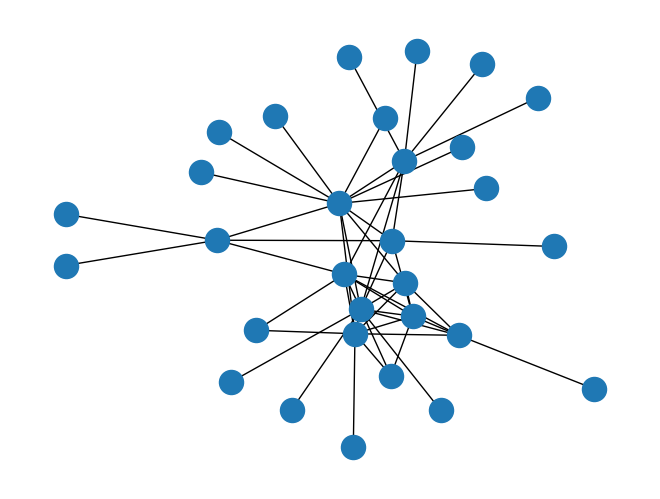

In [3]:
# generate graph
G = nx.random_internet_as_graph(n=NUMBER_OF_NODES, seed=RANDOM_SEED)
nx.draw(G)

In [4]:
# assigning node types
for node in G.nodes():
    if G.degree[node] > 5:
        G.nodes[node]['type'] = NodeType.SERVER
    else:
        G.nodes[node]['type'] = random.choice([NodeType.CCTV, NodeType.SWITCH, NodeType.COMPUTER, NodeType.LINK])

In [5]:
# init empty link dict
links_dict: Dict[str, Link] = {}

# iterate over each edge
for index, (src_node, dest_node, data) in enumerate(G.edges(data=True)):
    # generate a unique ID for each link
    link_id = f"{index}"
    
    # get the names and IDs of the source and destination nodes
    src_node_id = str(src_node)
    src_node_name = f"Node_{src_node_id}"
    dest_node_id = str(dest_node)
    dest_node_name = f"Node_{dest_node_id}"
    
    # define bandwidth and services (protocols) for this link
    bandwidth = random.randint(100, 1000)  # random bandwidth between 100 and 1000 bps
    services = ["HTTP", "SSH"]  # TODO: modify these as neccesary
    
    # create the Link object
    link = Link(
        _name=link_id,
        _id=link_id,
        _bandwidth=bandwidth,
        _source_node_id=src_node_id,
        _source_node_name=src_node_name,
        _dest_node_id=dest_node_id,
        _dest_node_name=dest_node_name,
        _services=services
    )
    
    # add the link to the `links_dict`
    links_dict[link_id] = link

example_link = links_dict["0"]
print("Example Dictionary Item:")
print(f"  Link ID: {example_link.id}, Source: {example_link.source_node_name}, Destination: {example_link.dest_node_name}, Bandwidth: {example_link.bandwidth}")

Example Dictionary Item:
  Link ID: 0, Source: Node_0, Destination: Node_1, Bandwidth: 640


In [6]:
# load the training config
training_config = load(TRAINING_CONFIG_PATH)

In [7]:
# init empty nodes dict
from primaite.common.service import Service


nodes_dict: Dict[str, NodeUnion] = {}

# additional default values for IP address, software state, and file system state
default_ip_address = "192.168.1.1"
default_software_state = SoftwareState.GOOD
default_file_system_state = FileSystemState.GOOD

# modify the node creation logic to include the required arguments
for node_id in G.nodes():
    # extract node attributes
    node_type = G.nodes[node_id]['type']
    node_name = f"Node_{node_id}"
    
    # determine priority and hardware state (for demonstration purposes, these are random)
    priority = random.choice(list(Priority))
    hardware_state = random.choice(list(HardwareState))
    
    # based on the node_type, create an appropriate NodeUnion instance
    if node_type == NodeType.SERVER or node_type == NodeType.COMPUTER:
        node = ServiceNode(
            node_id=str(node_id),
            name=node_name,
            node_type=node_type,
            priority=priority,
            hardware_state=hardware_state,
            ip_address=default_ip_address,
            software_state=default_software_state,
            file_system_state=default_file_system_state,
            config_values=training_config
        )

        node.add_service(Service(name="HTTP", port="80", software_state=default_software_state))
        node.add_service(Service(name="SSH", port="22", software_state=default_software_state))
        # node.add_service(name="FTP", port="21": software_state=SoftwareState.Good)

    else:
        node = ActiveNode(
            node_id=str(node_id),
            name=node_name,
            node_type=node_type,
            priority=priority,
            hardware_state=hardware_state,
            ip_address=default_ip_address,
            software_state=default_software_state,
            file_system_state=default_file_system_state,
            config_values=training_config
        )
    
    # add the node to the `nodes_dict`
    nodes_dict[str(node_id)] = node

print("Example Node Item:")
for node_id, node in nodes_dict.items():
    if (node_id == "0"):
        print(f"Node ID: {node_id}, Node Name: {node.name}, Node Type: {node.node_type.name}")

Example Node Item:
Node ID: 0, Node Name: Node_0, Node Type: SERVER


In [8]:
service_names = ["HTTP", "SSH", "FTP"]  # TODO: replace with actual service names relevant to your network
ports_list = ["80", "22", "21"]  # TODO: replace with actual ports relevant to your network

network = Network(
    nodes_dict=nodes_dict, 
    links_dict=links_dict, 
    service_names=service_names, 
    ports_list=ports_list, 
    graph=G
)

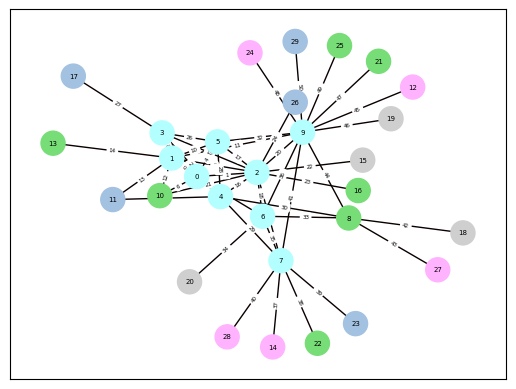

In [9]:
network.display_graph()

In [10]:
network.nodes_table().head()

,Name,Hardware State,Software State,File System State,HTTP Service State,SSH Service State,FTP Service State
1,Node_0,RESETTING,GOOD,GOOD,GOOD,GOOD,-
2,Node_1,RESETTING,GOOD,GOOD,GOOD,GOOD,-
3,Node_2,-,GOOD,GOOD,GOOD,GOOD,-
4,Node_3,SHUTTING_DOWN,GOOD,GOOD,GOOD,GOOD,-
5,Node_4,RESETTING,GOOD,GOOD,GOOD,GOOD,-


In [11]:
network.traffic_table().head()

,Name,HTTP Traffic,SSH Traffic,FTP Traffic
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0


In [12]:
network.serialize()

[{'item_type': 'PORTS',
  'ports_list': [{'port': '80'}, {'port': '22'}, {'port': '21'}]},
 {'item_type': 'SERVICES',
  'service_list': [{'name': 'HTTP'}, {'name': 'SSH'}, {'name': 'FTP'}]},
 {'item_type': 'NODE',
  'node_id': '0',
  'name': 'Node_0',
  'node_class': 'SERVICE',
  'node_type': 'SERVER',
  'priority': 'P1',
  'hardware_state': 'RESETTING',
  'ip_address': '192.168.1.1',
  'software_state': 'GOOD',
  'file_system_state': 'GOOD',
  'services': [{'name': 'HTTP', 'port': '80', 'state': 'GOOD'},
   {'name': 'SSH', 'port': '22', 'state': 'GOOD'}]},
 {'item_type': 'NODE',
  'node_id': '1',
  'name': 'Node_1',
  'node_class': 'SERVICE',
  'node_type': 'SERVER',
  'priority': 'P5',
  'hardware_state': 'RESETTING',
  'ip_address': '192.168.1.1',
  'software_state': 'GOOD',
  'file_system_state': 'GOOD',
  'services': [{'name': 'HTTP', 'port': '80', 'state': 'GOOD'},
   {'name': 'SSH', 'port': '22', 'state': 'GOOD'}]},
 {'item_type': 'NODE',
  'node_id': '2',
  'name': 'Node_2',
  

In [13]:
network.save("../data/laydown_configs/hey_buddy.yaml")